In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
parent_dir = 'results/trajs:360_blocks:3_imgs_2cams_903.661K_interp_0.85/ep:4400/image_model_img_task_enc'
file_path = os.path.join(parent_dir, 'all_states_image_model')

with open(file_path, 'rb') as f:
    data = pickle.load(f)

print('Type:', type(data))
print('Length (number of episodes):', len(data))

if len(data) > 0:
    print('\nFirst episode:')
    print('  Type:', type(data[0]))
    print('  Length (timesteps):', len(data[0]))
    
    if len(data[0]) > 0:
        print('\n  First timestep:')
        print('    Type:', type(data[0][0]))
        print('    Length (state dims):', len(data[0][0]))
        print('    Values:', data[0][0])
        
        print('\n  Last timestep:')
        print('    Values:', data[0][-1])

Type: <class 'list'>
Length (number of episodes): 18

First episode:
  Type: <class 'list'>
  Length (timesteps): 180

  First timestep:
    Type: <class 'list'>
    Length (state dims): 14
    Values: [1.4893193244934082, 1.1918010711669922, 1.2218854427337646, 1.3728642463684082, -0.5981074571609497, 1.1226798295974731, 0.5808099508285522, -0.04033420979976654, -0.012268283404409885, -0.018491106107831, 0.03092031739652157, -0.003728765295818448, -0.034486137330532074, 0.011697381734848022]

  Last timestep:
    Values: [1.2221906185150146, 0.9692727327346802, 1.0318493843078613, 1.8505291938781738, -0.520154595375061, 0.984632670879364, 0.7868494391441345, -0.02923961915075779, -0.012144641950726509, -0.015325724147260189, 0.016748886555433273, -0.000604189932346344, -0.03209641948342323, 0.00565408356487751]


In [9]:
# Select episode to plot
episode_idx = 7
episode_data = np.array(data[episode_idx])

# Stored data at index k: [physical_{k+1}, vel_k]
# So: physical_joints[k] = physical at timestep k+1
#     velocities[k] = vel at timestep k
physical_joints = episode_data[:, :7]    # shape: (T, 7)
velocities = episode_data[:, 7:]          # shape: (T, 7)

# Reconstruct theory values:
# theory_{k+1} = physical_k + 5 * vel_k
# In stored indices: theory[k] = physical_joints[k-1] + 5 * velocities[k]
# For k=1 to T-1:
theory_joints = physical_joints[:-1] + 5 * velocities[1:]  # shape: (T-1, 7)

# Compare theory[k] with physical_joints[k] for k=1 to T-1
physical_for_comparison = physical_joints[1:]  # physical at k=1 to T-1

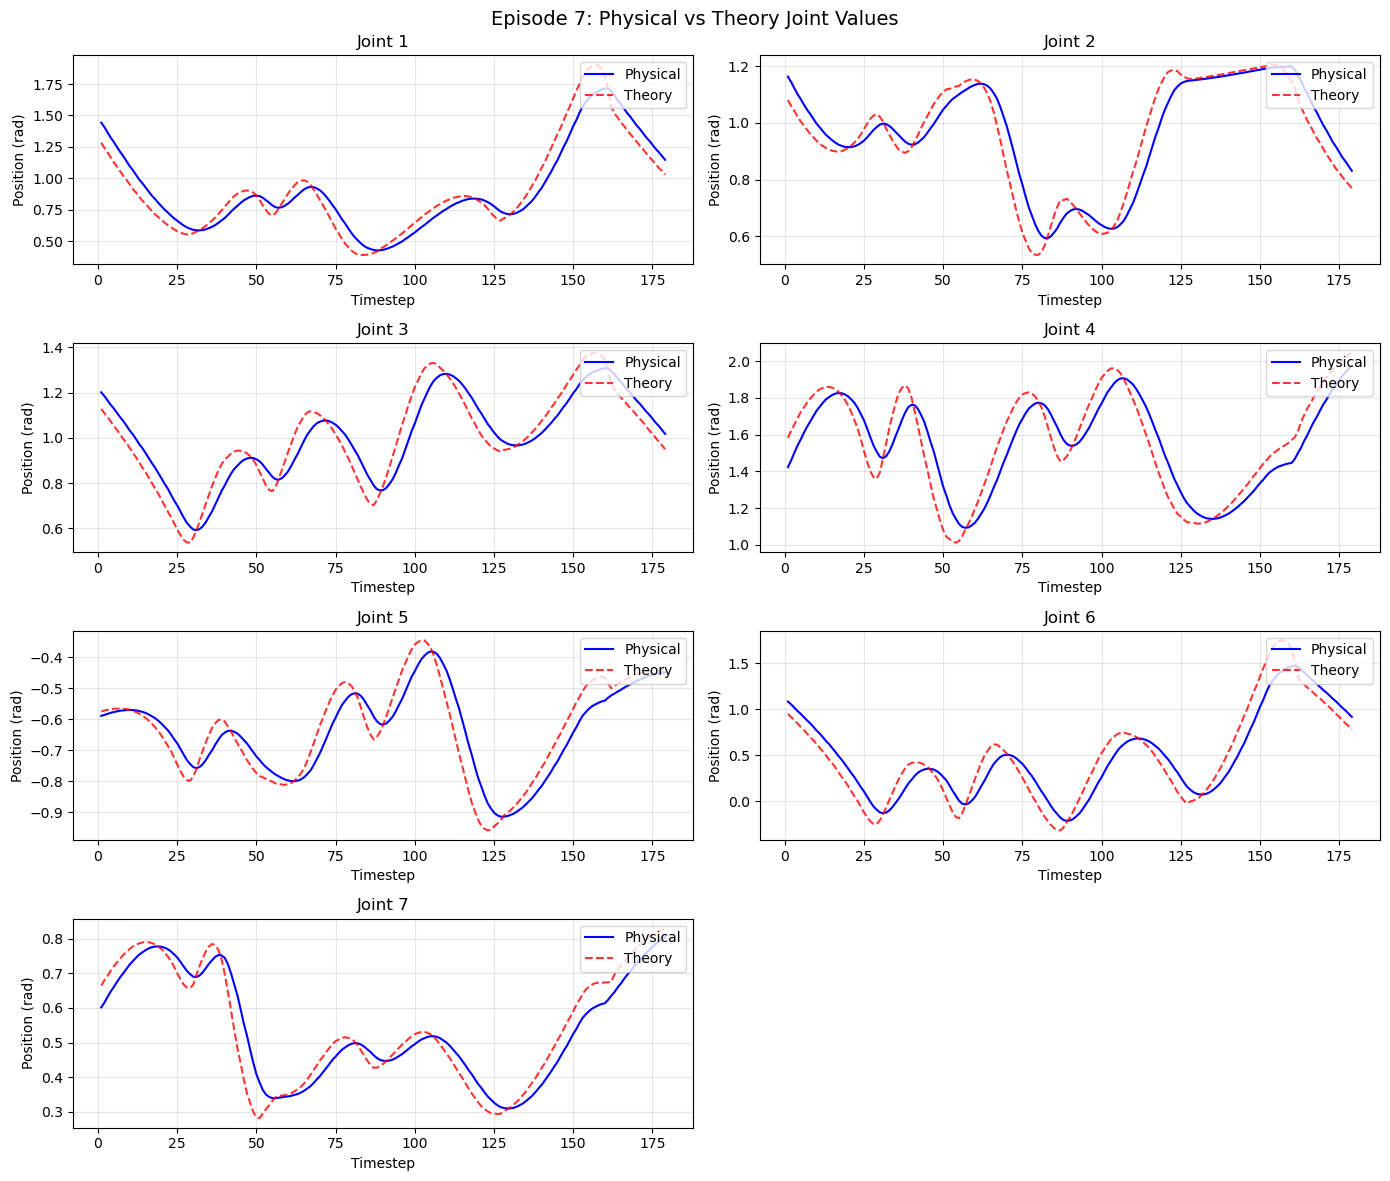

In [10]:
# Plot physical vs theory for each joint
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

timesteps = np.arange(1, len(physical_for_comparison) + 1)

for j in range(7):
    ax = axes[j]
    ax.plot(timesteps, physical_for_comparison[:, j], 'b-', label='Physical', linewidth=1.5)
    ax.plot(timesteps, theory_joints[:, j], 'r--', label='Theory', linewidth=1.5, alpha=0.8)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Position (rad)')
    ax.set_title(f'Joint {j+1}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# Hide the 8th subplot
axes[7].axis('off')

plt.suptitle(f'Episode {episode_idx}: Physical vs Theory Joint Values', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(parent_dir, f'physic_v_theory_ep{episode_idx}.png'))
plt.show()

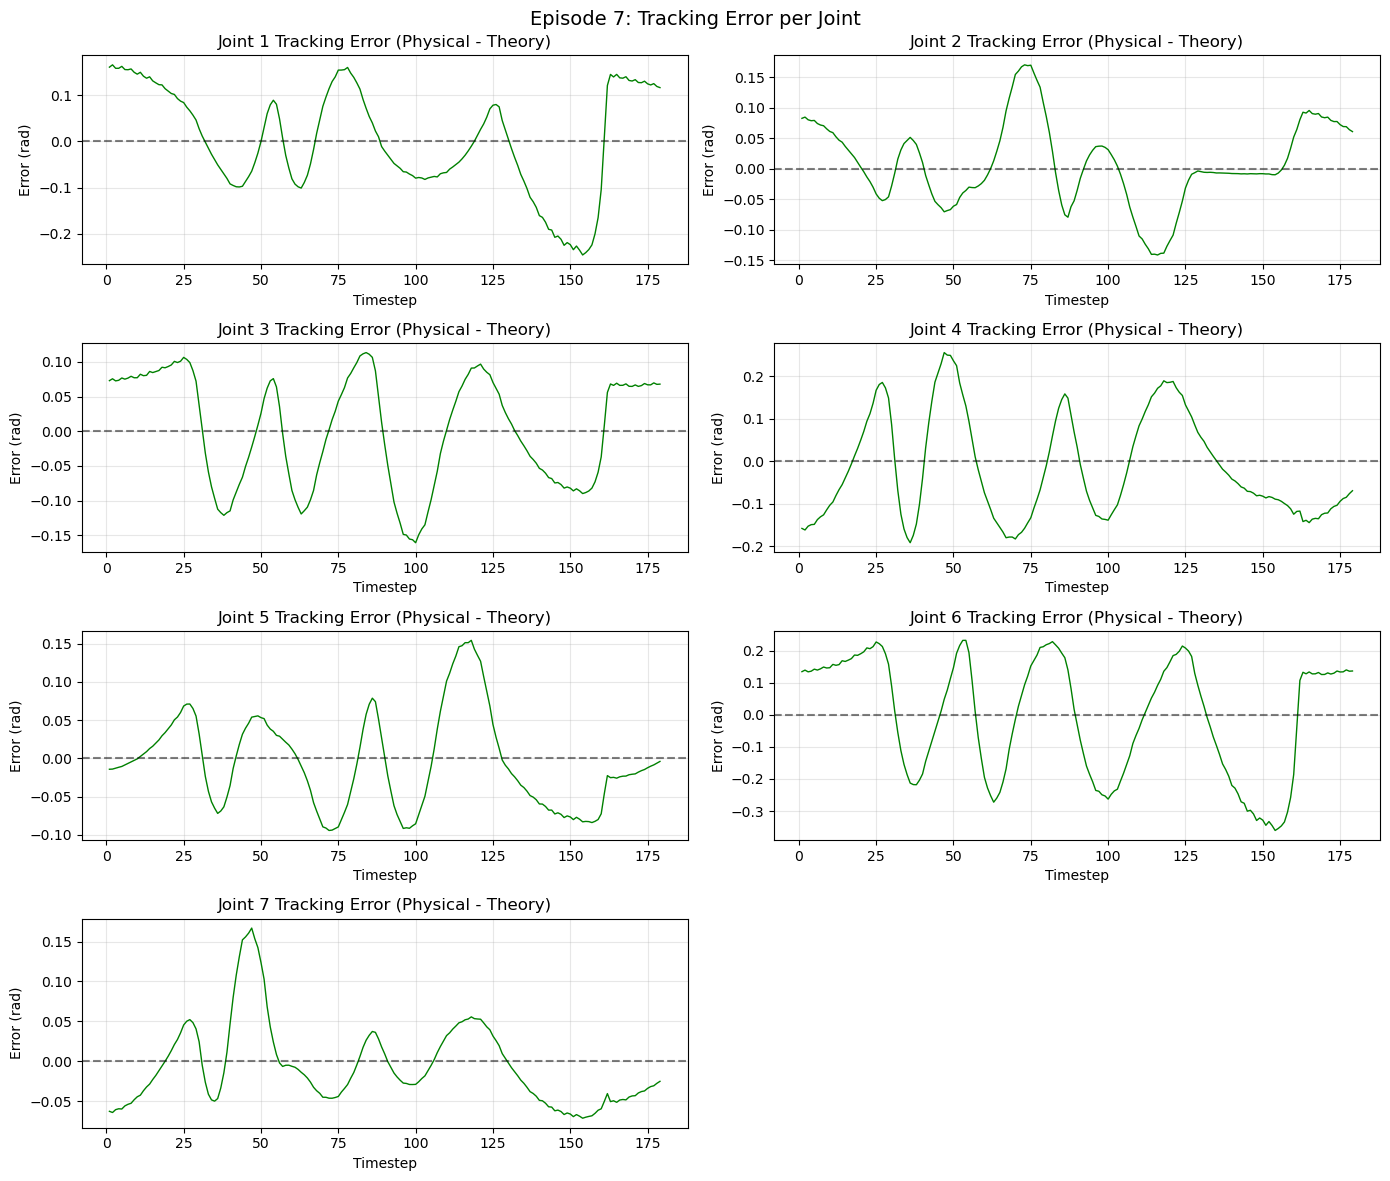

In [11]:
# Also show the tracking error (physical - theory)
fig2, axes2 = plt.subplots(4, 2, figsize=(14, 12))
axes2 = axes2.flatten()

for j in range(7):
    ax = axes2[j]
    error = physical_for_comparison[:, j] - theory_joints[:, j]
    ax.plot(timesteps, error, 'g-', linewidth=1)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Error (rad)')
    ax.set_title(f'Joint {j+1} Tracking Error (Physical - Theory)')
    ax.grid(True, alpha=0.3)

axes2[7].axis('off')
plt.suptitle(f'Episode {episode_idx}: Tracking Error per Joint', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(parent_dir, f'error_physic_v_theory_ep{episode_idx}.png'))
plt.show()

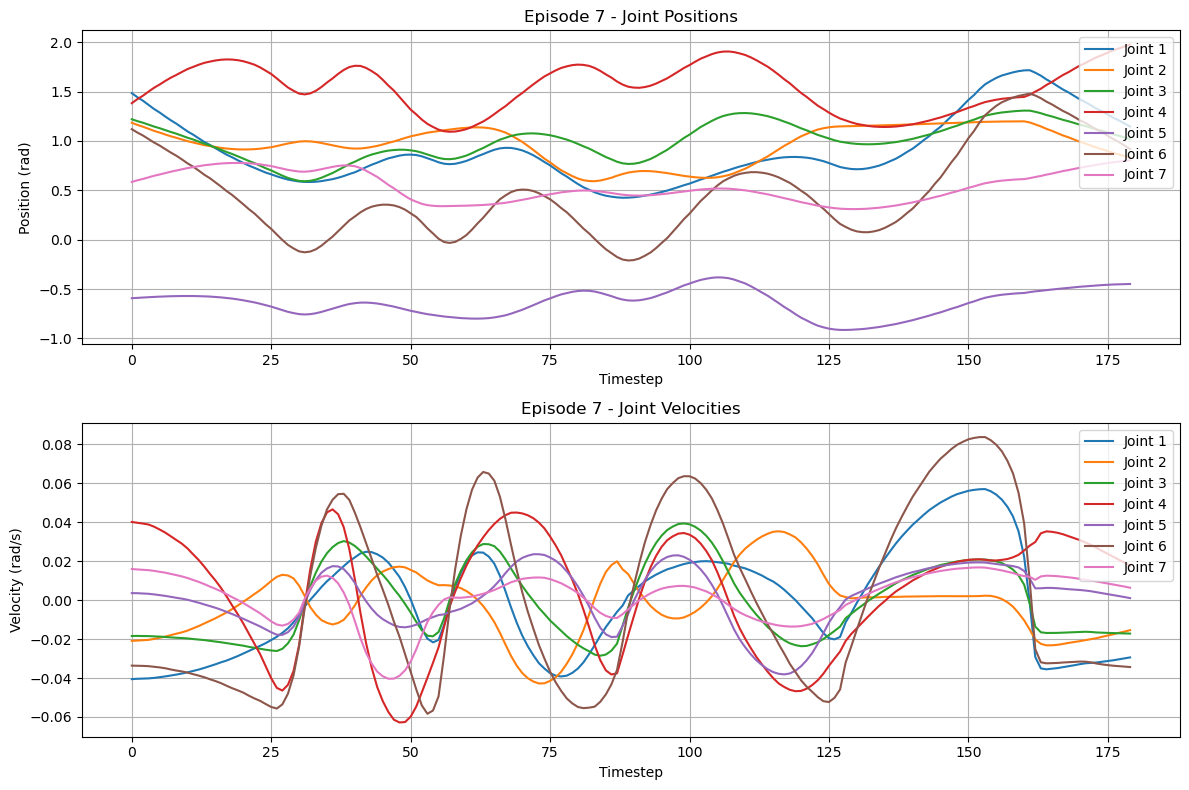

In [12]:
# Plot joint positions
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Joint positions
for j in range(7):
    axes[0].plot(physical_joints[:, j], label=f'Joint {j+1}')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Position (rad)')
axes[0].set_title(f'Episode {episode_idx} - Joint Positions')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Joint velocities
for j in range(7):
    axes[1].plot(velocities[:, j], label=f'Joint {j+1}')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Velocity (rad/s)')
axes[1].set_title(f'Episode {episode_idx} - Joint Velocities')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.show()